# Tom and Jerry CNN classification
Train on dataset with one config: Dropout + Data Augmentation from provided tutorial  in instruction file

In [1]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import kagglehub

In [2]:
path = kagglehub.dataset_download("balabaskar/tom-and-jerry-image-classification")
source_dir = os.path.join(path, "tom_and_jerry", "tom_and_jerry")

# Use local dataset/ directory (created under current working directory)
data_dir = os.path.join("dataset")
os.makedirs(data_dir, exist_ok=True)

# Copy class folders from Kaggle cache into dataset/
for name in os.listdir(source_dir):
    src = os.path.join(source_dir, name)
    dst = os.path.join(data_dir, name)
    if os.path.isdir(src):
        if os.path.exists(dst):
            shutil.rmtree(dst)
        shutil.copytree(src, dst)

print("Dataset:", os.path.abspath(data_dir))

100%|██████████| 435M/435M [00:21<00:00, 21.3MB/s] 

Extracting files...


Dataset: /content/dataset


In [3]:
batch_size = 32
img_height = 180
img_width = 180

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 5478 files belonging to 4 classes.
Using 4383 files for training.
Found 5478 files belonging to 4 classes.
Using 1095 files for validation.
Classes: ['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']


In [4]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
# Data augmentation from tutorial (tutorial: https://www.tensorflow.org/tutorials/images/classification)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Model from TensorFlow tutorial (with data augmentation + Dropout) from the tutorial
model = Sequential([
    data_augmentation,
    layers.Rescaling(1.0 / 255),
    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),

    
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes),
])
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,156 (15.22 MB)

 Trainable params: 3,989,156 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
epochs = 15
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

h = history.history
best_ep = np.argmax(h["val_accuracy"])
train_acc_best = h["accuracy"][best_ep]
train_loss_best = h["loss"][best_ep]
val_acc_best = h["val_accuracy"][best_ep]
val_loss_best = h["val_loss"][best_ep]

Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.3392 - loss: 1.3600 - val_accuracy: 0.3872 - val_loss: 1.2907
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.3999 - loss: 1.2761 - val_accuracy: 0.4995 - val_loss: 1.1132
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5135 - loss: 1.0946 - val_accuracy: 0.5854 - val_loss: 0.9484
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.5961 - loss: 0.9362 - val_accuracy: 0.6393 - val_loss: 0.8971
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6636 - loss: 0.8125 - val_accuracy: 0.6758 - val_loss: 0.7446
Epoch 6/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6806 - loss: 0.7577 - val_accuracy: 0.7233 - val_loss: 0.6553
Epoch 7/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.7154 - loss: 0.7069 - val_accuracy: 0.6932 - val_loss: 0.7703
Epoch 8/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7351 - loss: 0.6398 - val_ac

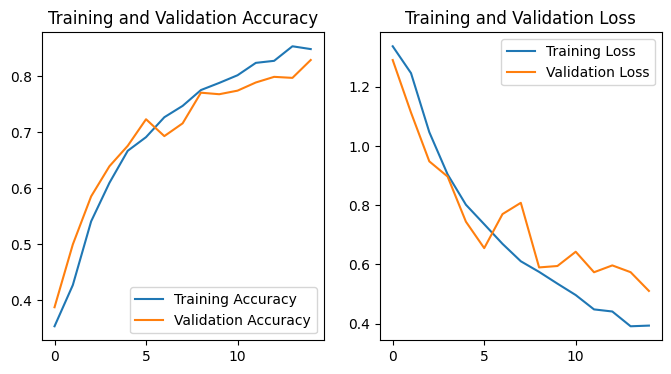

In [8]:
# Visualize training results (tutorial: https://www.tensorflow.org/tutorials/images/classification)
epochs_range = range(epochs)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, h["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, h["val_accuracy"], label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.subplot(1, 2, 2)
plt.plot(epochs_range, h["loss"], label="Training Loss")
plt.plot(epochs_range, h["val_loss"], label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

## Best model summary

In [9]:
print("Training Accuracy and Loss of the model:", round(train_acc_best, 4), round(train_loss_best, 4))
print("Validation Accuracy and Loss of the model:", round(val_acc_best, 4), round(val_loss_best, 4))
val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print("Validation set (final): accuracy", round(val_acc, 4), "loss", round(val_loss, 4))

Training Accuracy and Loss of the model: 0.8487 0.3935
Validation Accuracy and Loss of the model: 0.8292 0.5107
Validation set (final): accuracy 0.8292 loss 0.5107


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


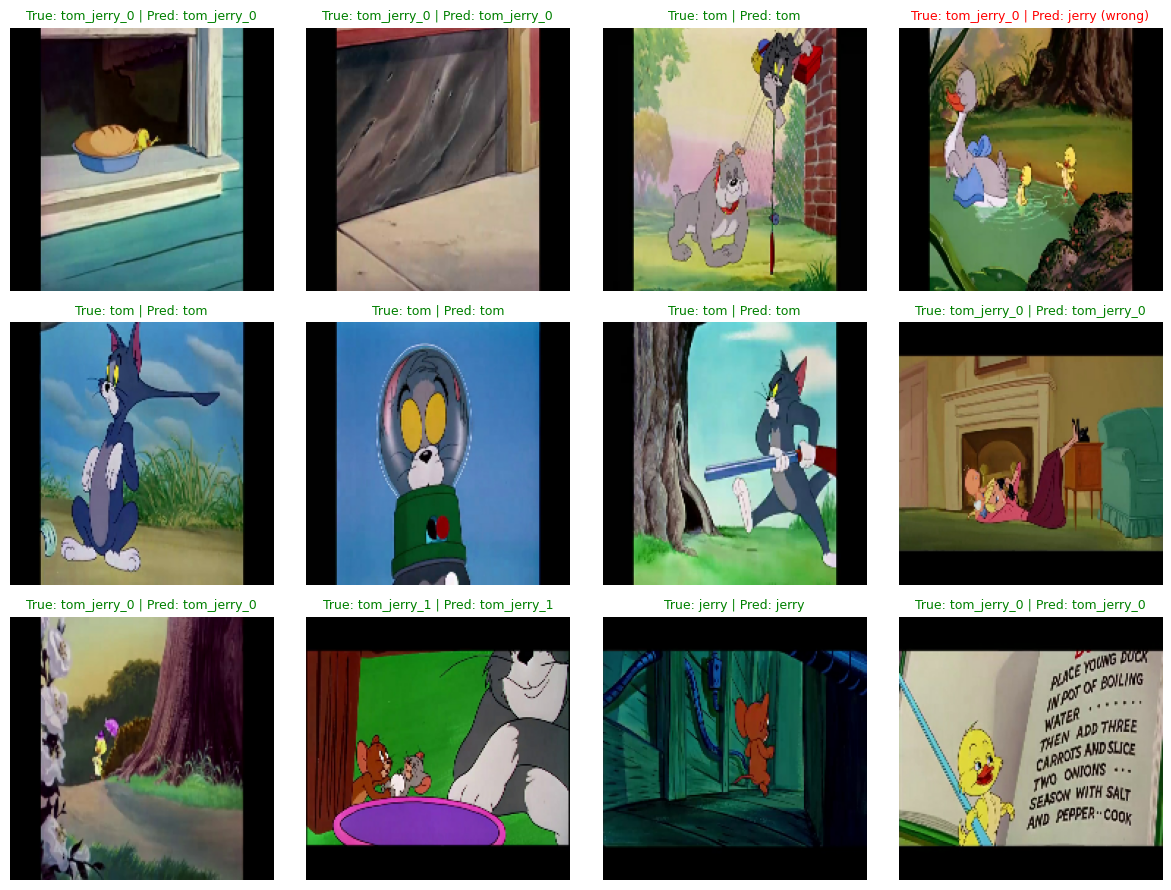

In [13]:
# Sample inputs: check if predictions are right or wrong
for images, labels in val_ds.take(1):
    break

predictions = model.predict(images)
pred_labels = np.argmax(predictions, axis=1)

n_show = min(12, len(images))
n_cols = 4
n_rows = (n_show + n_cols - 1) // n_cols

plt.figure(figsize=(12, 3 * n_rows))
for i in range(n_show):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    true_name = class_names[labels[i]]
    pred_name = class_names[pred_labels[i]]
    correct = labels[i] == pred_labels[i]
    color = "green" if correct else "red"
    title = f"True: {true_name} | Pred: {pred_name}"
    if not correct:
        title += " (wrong)"
    plt.title(title, color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()